In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Telco_customer_churn.csv")
print("Shape:", df.shape)

In [20]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [22]:
# 1. Remove exact duplicate rows
before = len(df)
df = df.drop_duplicates()
print(df.drop_duplicates())

      CustomerID  Count        Country       State          City  Zip Code  \
0     3668-QPYBK      1  United States  California   Los Angeles     90003   
1     9237-HQITU      1  United States  California   Los Angeles     90005   
2     9305-CDSKC      1  United States  California   Los Angeles     90006   
3     7892-POOKP      1  United States  California   Los Angeles     90010   
4     0280-XJGEX      1  United States  California   Los Angeles     90015   
...          ...    ...            ...         ...           ...       ...   
7038  2569-WGERO      1  United States  California       Landers     92285   
7039  6840-RESVB      1  United States  California      Adelanto     92301   
7040  2234-XADUH      1  United States  California         Amboy     92304   
7041  4801-JZAZL      1  United States  California  Angelus Oaks     92305   
7042  3186-AJIEK      1  United States  California  Apple Valley     92308   

                    Lat Long   Latitude   Longitude  Gender  ..

In [24]:
print("Duplicate CustomerIDs:", df['CustomerID'].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Duplicate CustomerIDs: 0
Fully duplicate rows: 0


In [25]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [26]:
# 3. Standardize text columns (City)
df["City"] = df["City"].astype(str).str.strip().str.title()
df["City"] = df["City"].replace("Nan", np.nan)
print(df["City"])

0        Los Angeles
1        Los Angeles
2        Los Angeles
3        Los Angeles
4        Los Angeles
            ...     
7038         Landers
7039        Adelanto
7040           Amboy
7041    Angelus Oaks
7042    Apple Valley
Name: City, Length: 7043, dtype: object


In [27]:
print("\nColumns and dtypes:")
print(df.dtypes)


Columns and dtypes:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object


In [28]:
missing = df.isnull().sum()
print(missing[missing > 0])

Churn Reason    5174
dtype: int64


In [29]:
# ---- CLEANING ----
df_clean = df.copy()

# Total Charges sometimes has blanks/spaces for tenure=0 customers
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
n_tc_missing = df_clean['Total Charges'].isnull().sum()
print(f"\n'Total Charges' non-numeric/missing entries coerced: {n_tc_missing}")



'Total Charges' non-numeric/missing entries coerced: 11


In [30]:
# These are new customers with 0 tenure -> fill with 0
df_clean.loc[df_clean['Tenure Months'] == 0, 'Total Charges'] = df_clean.loc[df_clean['Tenure Months'] == 0, 'Total Charges'].fillna(0)
df_clean['Total Charges'] = df_clean['Total Charges'].fillna(df_clean['Monthly Charges'])
 

In [31]:
# These are new customers with 0 tenure -> fill with 0
df_clean.loc[df_clean['Tenure Months'] == 0, 'Total Charges'] = df_clean.loc[df_clean['Tenure Months'] == 0, 'Total Charges'].fillna(0)
df_clean['Total Charges'] = df_clean['Total Charges'].fillna(df_clean['Monthly Charges'])

In [32]:
# Churn Reason is NaN for non-churned customers - that's expected, fill explicitly
df_clean['Churn Reason'] = df_clean['Churn Reason'].fillna('Not Applicable (Active Customer)')
 
# Drop columns not useful for behavior analysis (geo lat/long string, count constant)
drop_cols = ['Count', 'Lat Long']
df_clean = df_clean.drop(columns=[c for c in drop_cols if c in df_clean.columns])
 
print("\nPost-cleaning missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])


Post-cleaning missing values:
Series([], dtype: int64)


In [33]:
df_clean.to_csv("Copy of Telco_customer_churn.csv", index=False)
print("\nCleaned dataset saved:", df_clean.shape)
 


Cleaned dataset saved: (7043, 31)


In [34]:
print("\n" + "="*60)
print("4. SUMMARY STATISTICS")
print("="*60)
print(df_clean[['Tenure Months','Monthly Charges','Total Charges','Churn Score','CLTV']].describe())
 
print("\n" + "="*60)
print("5. CHURN OVERVIEW")
print("="*60)
churn_rate = df_clean['Churn Value'].mean()*100
print(f"Overall churn rate: {churn_rate:.2f}%")
print(df_clean['Churn Label'].value_counts())


4. SUMMARY STATISTICS
       Tenure Months  Monthly Charges  Total Charges  Churn Score         CLTV
count    7043.000000      7043.000000    7043.000000  7043.000000  7043.000000
mean       32.371149        64.761692    2279.734304    58.699418  4400.295755
std        24.559481        30.090047    2266.794470    21.525131  1183.057152
min         0.000000        18.250000       0.000000     5.000000  2003.000000
25%         9.000000        35.500000     398.550000    40.000000  3469.000000
50%        29.000000        70.350000    1394.550000    61.000000  4527.000000
75%        55.000000        89.850000    3786.600000    75.000000  5380.500000
max        72.000000       118.750000    8684.800000   100.000000  6500.000000

5. CHURN OVERVIEW
Overall churn rate: 26.54%
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


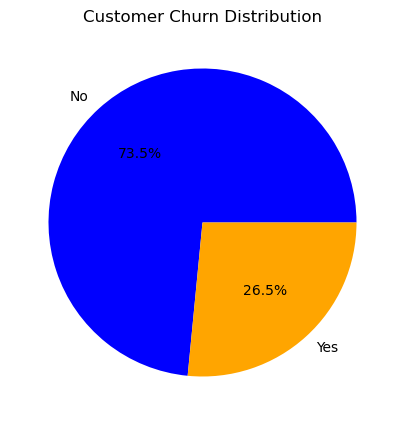

In [35]:
# 1. Churn distribution
plt.figure(figsize=(5,5))
df_clean['Churn Label'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['blue','orange'], ylabel='')
plt.title('Customer Churn Distribution')
plt.show()

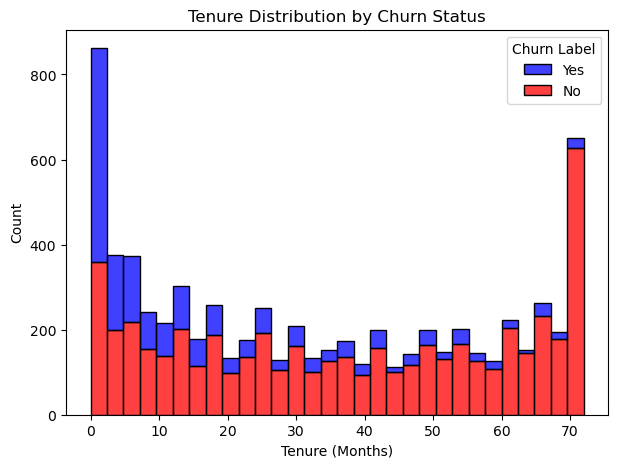

In [36]:
# 2. Tenure distribution by churn
plt.figure(figsize=(7,5))
sns.histplot(data=df_clean, x='Tenure Months', hue='Churn Label', multiple='stack', bins=30, palette=['blue','red'])
plt.title('Tenure Distribution by Churn Status')
plt.xlabel('Tenure (Months)')
plt.show()

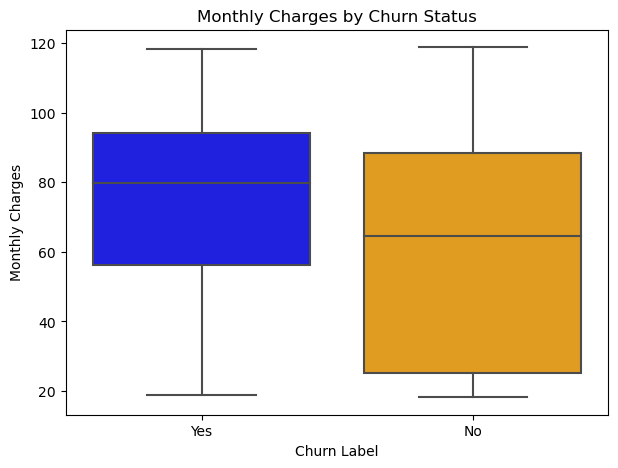

In [37]:
# 3. Monthly charges vs churn
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean, x='Churn Label', y='Monthly Charges', palette=['blue','orange'])
plt.title('Monthly Charges by Churn Status')
plt.show()

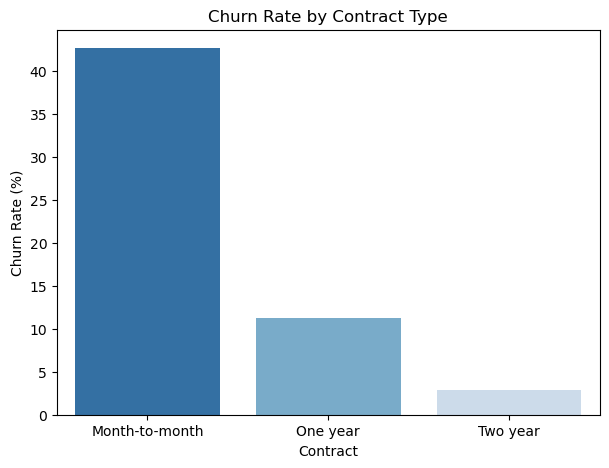

In [38]:
# 4. Contract type vs churn rate
plt.figure(figsize=(7,5))
contract_churn = df_clean.groupby('Contract')['Churn Value'].mean().sort_values(ascending=False)*100
sns.barplot(x=contract_churn.index, y=contract_churn.values, palette='Blues_r')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Contract Type')
plt.show()

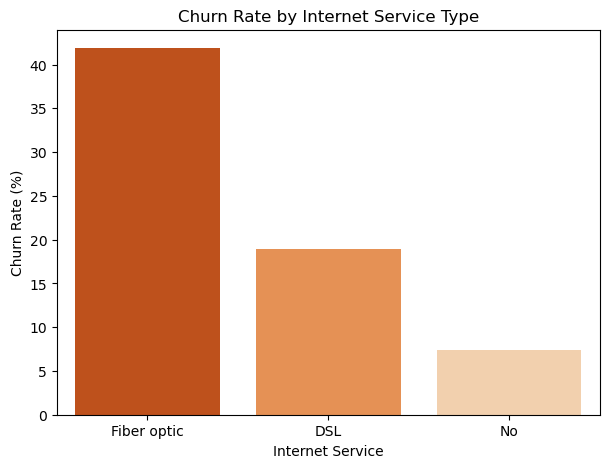

In [39]:
# 5. Internet service vs churn rate
plt.figure(figsize=(7,5))
inet_churn = df_clean.groupby('Internet Service')['Churn Value'].mean().sort_values(ascending=False)*100
sns.barplot(x=inet_churn.index, y=inet_churn.values, palette='Oranges_r')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Internet Service Type')
plt.show()

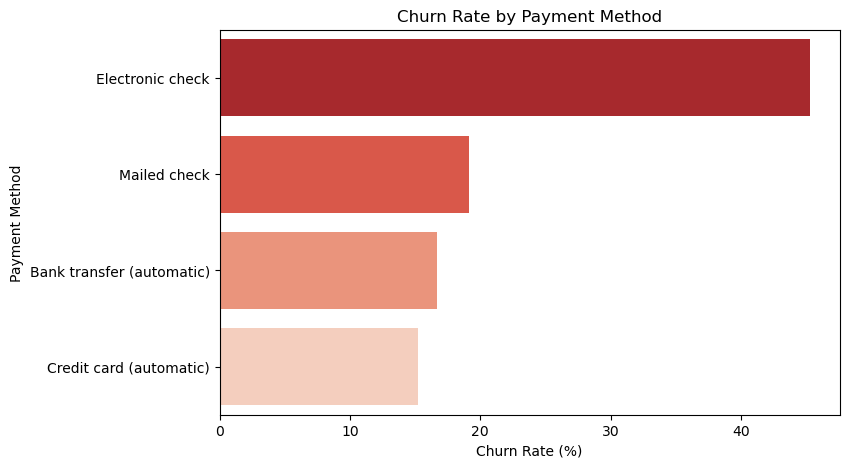

In [40]:
# 6. Payment method vs churn rate
plt.figure(figsize=(8,5))
pay_churn = df_clean.groupby('Payment Method')['Churn Value'].mean().sort_values(ascending=False)*100
sns.barplot(x=pay_churn.values, y=pay_churn.index, palette='Reds_r')
plt.xlabel('Churn Rate (%)')
plt.title('Churn Rate by Payment Method')
plt.show()

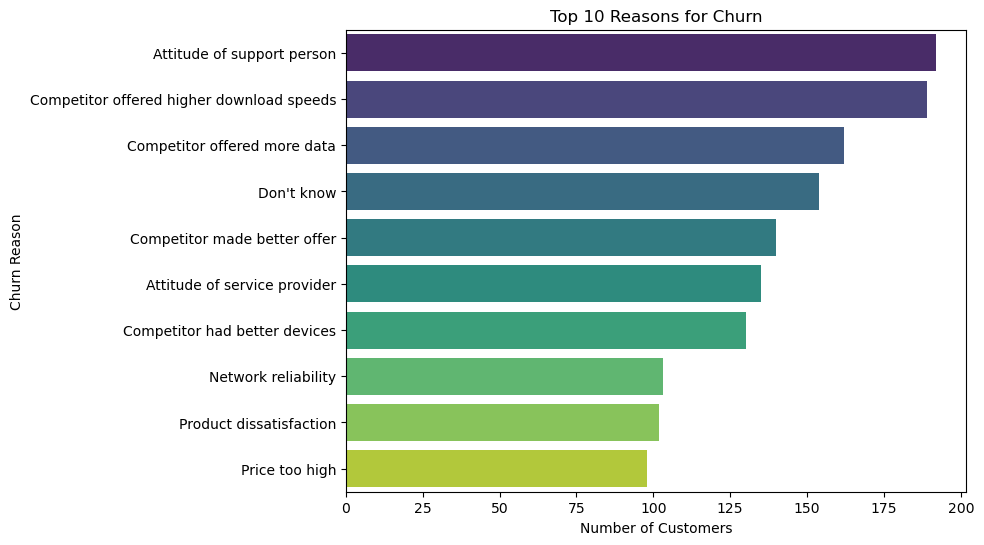

In [41]:
# 7. Top churn reasons
plt.figure(figsize=(8,6))
top_reasons = df_clean[df_clean['Churn Value']==1]['Churn Reason'].value_counts().head(10)
sns.barplot(x=top_reasons.values, y=top_reasons.index, palette='viridis')
plt.xlabel('Number of Customers')
plt.title('Top 10 Reasons for Churn')
plt.show()
 

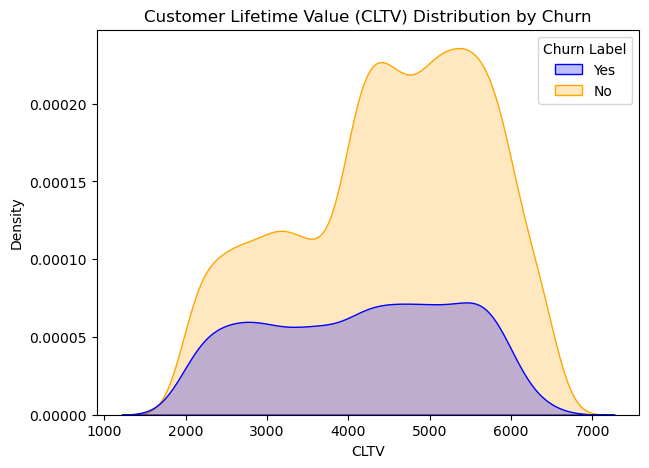

In [42]:
# 8. CLTV distribution by churn
plt.figure(figsize=(7,5))
sns.kdeplot(data=df_clean, x='CLTV', hue='Churn Label', fill=True, palette=['blue','orange'])
plt.title('Customer Lifetime Value (CLTV) Distribution by Churn')
plt.show()

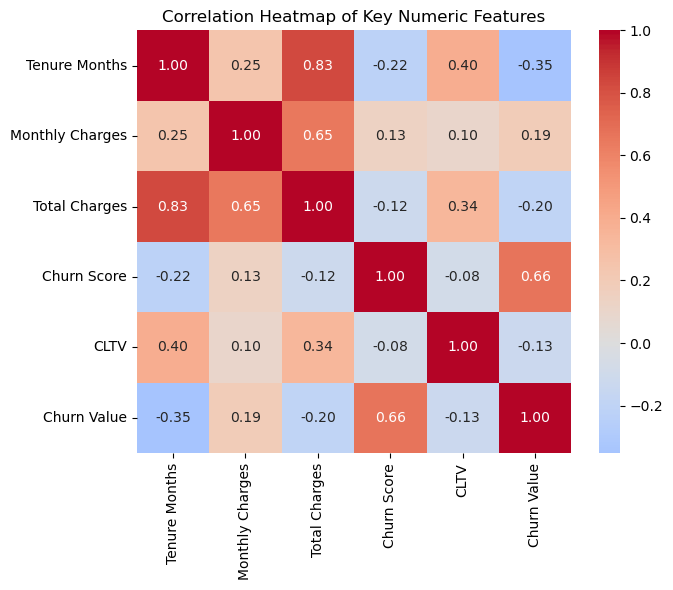

In [43]:
# 9. Correlation heatmap of numeric features
plt.figure(figsize=(7,6))
num_cols = ['Tenure Months','Monthly Charges','Total Charges','Churn Score','CLTV','Churn Value']
corr = df_clean[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap of Key Numeric Features')
plt.tight_layout()
plt.show()

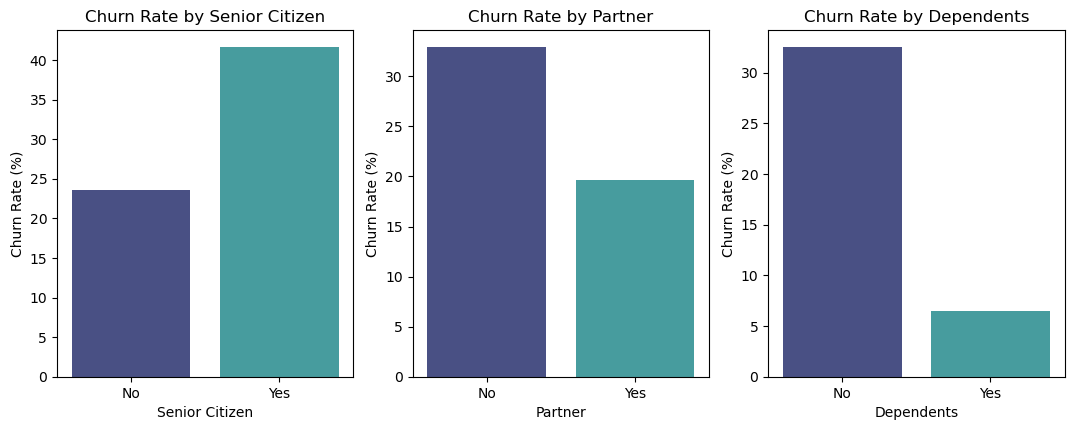

In [44]:
# 10. Senior citizen / dependents / partner vs churn
fig, axes = plt.subplots(1,3, figsize=(13,4.5))
for ax, col in zip(axes, ['Senior Citizen','Partner','Dependents']):
    rates = df_clean.groupby(col)['Churn Value'].mean()*100
    sns.barplot(x=rates.index, y=rates.values, ax=ax, palette='mako')
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate (%)')
plt.show()

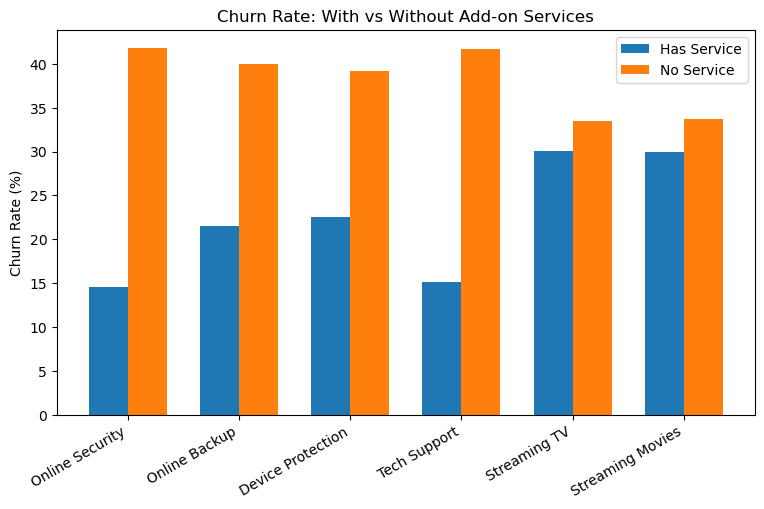

In [45]:
# 11. Streaming/addon services vs churn
addon_cols = ['Online Security','Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies']
rates = {c: df_clean[df_clean[c]=='Yes']['Churn Value'].mean()*100 for c in addon_cols}
rates_no = {c: df_clean[df_clean[c]=='No']['Churn Value'].mean()*100 for c in addon_cols}
plt.figure(figsize=(9,5))
x = np.arange(len(addon_cols))
w=0.35
plt.bar(x-w/2, list(rates.values()), w, label='Has Service')
plt.bar(x+w/2, list(rates_no.values()), w, label='No Service')
plt.xticks(x, addon_cols, rotation=30, ha='right')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate: With vs Without Add-on Services')
plt.legend()
plt.show()

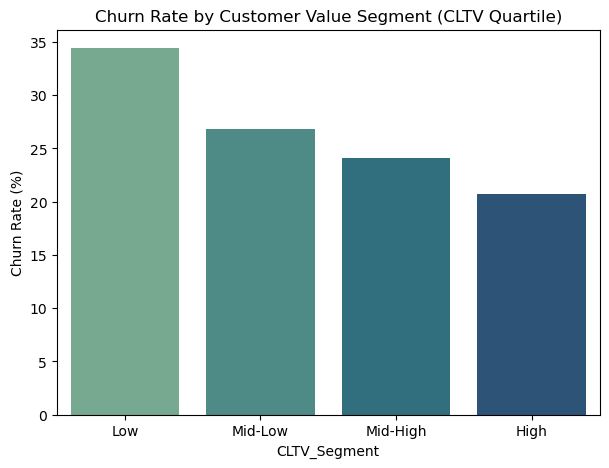

In [46]:
# 12. High value vs churn - customer segmentation by CLTV quartile
df_clean['CLTV_Segment'] = pd.qcut(df_clean['CLTV'], 4, labels=['Low','Mid-Low','Mid-High','High'])
plt.figure(figsize=(7,5))
seg_churn = df_clean.groupby('CLTV_Segment')['Churn Value'].mean()*100
sns.barplot(x=seg_churn.index, y=seg_churn.values, palette='crest')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Value Segment (CLTV Quartile)')
plt.show()

In [44]:
# Save key insight numbers for the report
insights = {
    "total_customers": len(df_clean),
    "churn_rate": churn_rate,
    "avg_tenure_churned": df_clean[df_clean['Churn Value']==1]['Tenure Months'].mean(),
    "avg_tenure_retained": df_clean[df_clean['Churn Value']==0]['Tenure Months'].mean(),
    "avg_monthly_churned": df_clean[df_clean['Churn Value']==1]['Monthly Charges'].mean(),
    "avg_monthly_retained": df_clean[df_clean['Churn Value']==0]['Monthly Charges'].mean(),
    "month_to_month_churn": contract_churn.get('Month-to-month', np.nan),
    "two_year_churn": contract_churn.get('Two year', np.nan),
    "fiber_churn": inet_churn.get('Fiber optic', np.nan),
    "dsl_churn": inet_churn.get('DSL', np.nan),
    "no_internet_churn": inet_churn.get('No', np.nan),
    "electronic_check_churn": pay_churn.get('Electronic check', np.nan),
    "top_reason_1": top_reasons.index[0] if len(top_reasons)>0 else None,
    "top_reason_1_count": int(top_reasons.iloc[0]) if len(top_reasons)>0 else None,
    "high_value_churn": seg_churn.get('High', np.nan),
    "low_value_churn": seg_churn.get('Low', np.nan),
    "avg_cltv_churned": df_clean[df_clean['Churn Value']==1]['CLTV'].mean(),
    "avg_cltv_retained": df_clean[df_clean['Churn Value']==0]['CLTV'].mean(),
}
import json
with open("Copy of Telco_customer_churn.csv","w") as f:
    json.dump(insights, f, indent=2, default=str)
print("\nInsights saved.")
for k,v in insights.items():
    print(k, ":", v)


Insights saved.
total_customers : 7043
churn_rate : 26.536987079369588
avg_tenure_churned : 17.979133226324237
avg_tenure_retained : 37.56996521066873
avg_monthly_churned : 74.44133226324237
avg_monthly_retained : 61.26512369540008
month_to_month_churn : 42.70967741935484
two_year_churn : 2.831858407079646
fiber_churn : 41.89276485788114
dsl_churn : 18.95910780669145
no_internet_churn : 7.404980340760157
electronic_check_churn : 45.28541226215645
top_reason_1 : Attitude of support person
top_reason_1_count : 192
high_value_churn : 20.726859738784782
low_value_churn : 34.429948950652296
avg_cltv_churned : 4149.414660246121
avg_cltv_retained : 4490.921337456513
